In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [2]:
# Config

DATASET_DIR = "dataset_mendeley"
IMG_SIZE = (224, 224)

In [3]:
# HSV threshold range tuned interactively on sample images
# (covers both green Unripe and yellow/spotted Ripe mangoes)
LOWER_HSV = np.array([15, 40, 40])
UPPER_HSV = np.array([85, 255, 255])

In [4]:
# Step 1-2: Load, Resize, Convert to HSV

def load_and_resize(image_path):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not read image: {image_path}")
    img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
    return img

In [5]:
# Step 3: HSV Thresholding + Morphological Cleanup

def segment_mango(img, lower=LOWER_HSV, upper=UPPER_HSV):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, lower, upper)
 
    # Morphological Open removes small noise specks, Close fills small holes
    # (e.g. dark spots on the peel that fall outside the HSV range)
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return mask

In [6]:
# Step 4: Contour Detection

def get_largest_contour(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    return max(contours, key=cv2.contourArea)

In [7]:
# Step 5: Shape Feature Extraction

def extract_shape_features(contour, img_shape):
    if contour is None:
        return np.zeros(9)
 
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
 
    # Normalise by image size so features are not just a proxy for resolution
    norm_area = area / (img_shape[0] * img_shape[1])
    norm_perimeter = perimeter / (img_shape[0] + img_shape[1])
 
    moments = cv2.moments(contour)
    hu_moments = cv2.HuMoments(moments).flatten()
    # Log-scale Hu Moments since raw values span a huge range
    hu_moments = -np.sign(hu_moments) * np.log10(np.abs(hu_moments) + 1e-10)
 
    return np.concatenate([[norm_area, norm_perimeter], hu_moments])

In [8]:
# Build dataset: loop through all class folders

def build_dataset(dataset_dir=DATASET_DIR):
    X, y = [], []
    classes = sorted(os.listdir(dataset_dir))
    for label in classes:
        class_dir = os.path.join(dataset_dir, label)
        if not os.path.isdir(class_dir):
            continue
        for fname in os.listdir(class_dir):
            fpath = os.path.join(class_dir, fname)
            image = cv2.imread(fpath)
            if image is None:
                print(f"Skipped (unreadable): {fpath}")
                continue
            image = cv2.resize(image, IMG_SIZE, interpolation=cv2.INTER_AREA)
            mask = segment_mango(image)
            contour = get_largest_contour(mask)
            features = extract_shape_features(contour, image.shape)
            X.append(features)
            y.append(label)
    return np.array(X), np.array(y)

In [9]:
X, y = build_dataset()
print("Total samples:", len(X))
print("Feature shape:", X.shape)
print("Class distribution:", {cls: list(y).count(cls) for cls in set(y)})

Total samples: 750
Feature shape: (750, 9)
Class distribution: {np.str_('pArtially_ripe'): 250, np.str_('unripe'): 250, np.str_('ripe'): 250}


In [10]:
from sklearn.ensemble import RandomForestClassifier

# Train + evaluate Random Forest across multiple n_estimators values

def evaluate_rf(X, y, n_estimators_values=(50, 100, 150, 200, 300)):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    results = {}
    for n in n_estimators_values:
        rf = RandomForestClassifier(n_estimators=n, random_state=42)
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
        rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
        f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

        results[n] = {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}
        print(f"n_estimators={n}: accuracy={acc:.4f}, precision={prec:.4f}, recall={rec:.4f}, f1={f1:.4f}")

    best_n = max(results, key=lambda n: results[n]["accuracy"])
    print(f"\nBest n_estimators = {best_n} (accuracy = {results[best_n]['accuracy']:.4f})")

    rf = RandomForestClassifier(n_estimators=best_n, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    print("\nPer-class report (best n_estimators):")
    print(classification_report(y_test, y_pred, zero_division=0))

    return results, best_n, rf

In [11]:
results_rf, best_n, best_rf_model = evaluate_rf(X, y)

n_estimators=50: accuracy=0.5133, precision=0.5164, recall=0.5133, f1=0.5137
n_estimators=100: accuracy=0.5333, precision=0.5377, recall=0.5333, f1=0.5340
n_estimators=150: accuracy=0.5267, precision=0.5295, recall=0.5267, f1=0.5272
n_estimators=200: accuracy=0.5133, precision=0.5152, recall=0.5133, f1=0.5133
n_estimators=300: accuracy=0.5067, precision=0.5094, recall=0.5067, f1=0.5063

Best n_estimators = 100 (accuracy = 0.5333)

Per-class report (best n_estimators):
                precision    recall  f1-score   support

pArtially_ripe       0.54      0.50      0.52        50
          ripe       0.59      0.54      0.56        50
        unripe       0.48      0.56      0.52        50

      accuracy                           0.53       150
     macro avg       0.54      0.53      0.53       150
  weighted avg       0.54      0.53      0.53       150



In [12]:
# Train + evaluate k-NN across multiple k values

def evaluate_knn(X, y, k_values=(3, 5, 7, 9, 11)):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    results = {}
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
        rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
        f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

        results[k] = {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}
        print(f"k={k}: accuracy={acc:.4f}, precision={prec:.4f}, recall={rec:.4f}, f1={f1:.4f}")

    best_k = max(results, key=lambda k: results[k]["accuracy"])
    print(f"\nBest k = {best_k} (accuracy = {results[best_k]['accuracy']:.4f})")

    knn = KNeighborsClassifier(n_neighbors=best_k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    print("\nPer-class report (best k):")
    print(classification_report(y_test, y_pred, zero_division=0))

    return results, best_k, knn

In [13]:
results, best_k, best_model = evaluate_knn(X, y)

k=3: accuracy=0.3800, precision=0.3837, recall=0.3800, f1=0.3794
k=5: accuracy=0.3733, precision=0.3778, recall=0.3733, f1=0.3750
k=7: accuracy=0.4467, precision=0.4447, recall=0.4467, f1=0.4434
k=9: accuracy=0.4867, precision=0.4848, recall=0.4867, f1=0.4824
k=11: accuracy=0.4867, precision=0.4852, recall=0.4867, f1=0.4835

Best k = 9 (accuracy = 0.4867)

Per-class report (best k):
                precision    recall  f1-score   support

pArtially_ripe       0.46      0.44      0.45        50
          ripe       0.49      0.40      0.44        50
        unripe       0.51      0.62      0.56        50

      accuracy                           0.49       150
     macro avg       0.48      0.49      0.48       150
  weighted avg       0.48      0.49      0.48       150



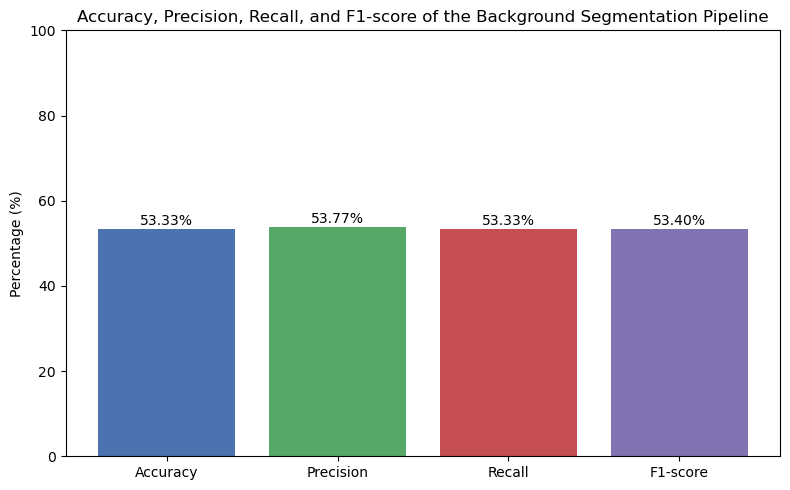

In [17]:
import matplotlib.pyplot as plt

# Use the metrics from your best Random Forest result (n_estimators=100)
metrics_names = ["Accuracy", "Precision", "Recall", "F1-score"]
metrics_values = [
    results_rf[best_n]["accuracy"] * 100,
    results_rf[best_n]["precision"] * 100,
    results_rf[best_n]["recall"] * 100,
    results_rf[best_n]["f1"] * 100,
]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(metrics_names, metrics_values, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
ax.set_ylim(0, 100)
ax.set_ylabel("Percentage (%)")
ax.set_title("Accuracy, Precision, Recall, and F1-score of the Background Segmentation Pipeline")

for bar, val in zip(bars, metrics_values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f"{val:.2f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("background_segmentation_metrics.png", dpi=200)
plt.show()

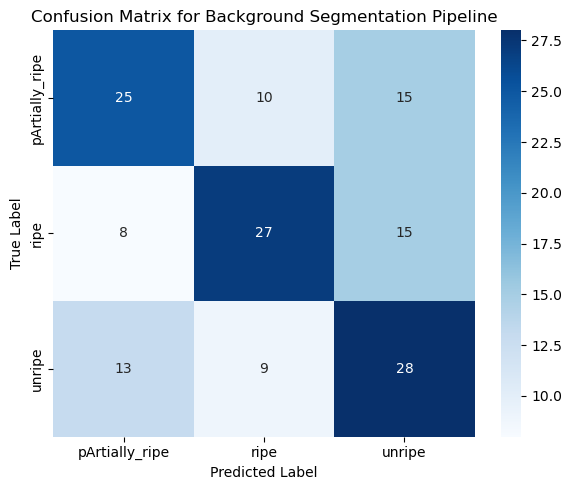

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Re-run with the best Random Forest model to get y_test and y_pred for the confusion matrix
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
final_rf = RandomForestClassifier(n_estimators=best_n, random_state=42)
final_rf.fit(X_train, y_train)
y_pred = final_rf.predict(X_test)

labels = sorted(set(y))
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix for Background Segmentation Pipeline")

plt.tight_layout()
plt.savefig("background_segmentation_confusion_matrix.png", dpi=200)
plt.show()

In [14]:
def process_single_image(image_path, show=True):
    img = load_and_resize(image_path)
    mask = segment_mango(img)
    contour = get_largest_contour(mask)
    features = extract_shape_features(contour, img.shape)

    if show:
        img_with_contour = img.copy()
        if contour is not None:
            cv2.drawContours(img_with_contour, [contour], -1, (0, 0, 255), 3)

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[0].set_title("Original"); axes[0].axis("off")
        axes[1].imshow(mask, cmap="gray"); axes[1].set_title("Mask"); axes[1].axis("off")
        axes[2].imshow(cv2.cvtColor(img_with_contour, cv2.COLOR_BGR2RGB)); axes[2].set_title("Contour"); axes[2].axis("off")
        plt.show()

    return features

In [15]:
def predict_ripeness(image_path, model=best_model):
    features = process_single_image(image_path, show=True)
    prediction = model.predict([features])[0]
    print(f"\nPredicted class: {prediction}")
    return prediction

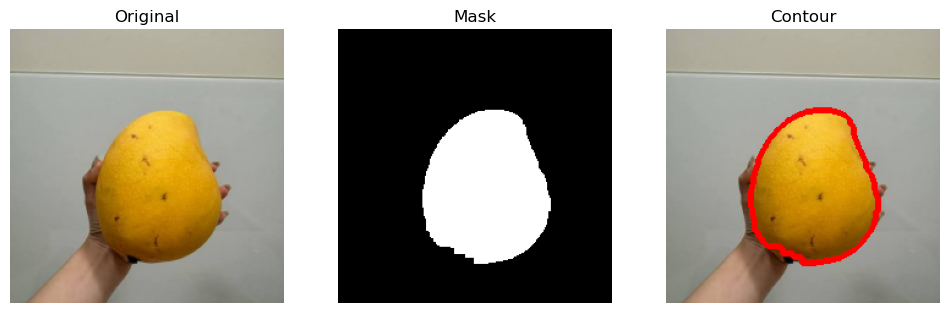


Predicted class: ripe


np.str_('ripe')

In [16]:
predict_ripeness("mango.jpg")